<a href="https://colab.research.google.com/github/aHawkins63/Feature-Engineering/blob/main/KNN_algorithm_fixed_withcardata_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import csv
import math
import operator
import random
import pandas as pd
import numpy

def splitdata(filename, train, test): # train and test parameters are effectively ignored as they are reassigned
    col_names = ['User ID', 'Gender', 'Age', 'AnnualSalary', 'Purchased']

    # Using the correct filename as provided in the context
    pima = pd.read_csv(filename, header=1, names=col_names)
    pima['Gender'] = pima['Gender'].replace(['Female', 'Male'], [0, 1])
    pima = pima.drop(['User ID'], axis=1)
    arr = pima.to_numpy()

    # The current split is fixed. Let's keep it this way to match the user's structure.
    # The last 100 rows are for testing. The rest for training.
    train_data = arr[0:len(arr) - 100]
    test_data = arr[len(arr) - 100:len(arr)] # Corrected slice to include the last element

    return train_data, test_data


def caldistance(train_set, testcase, distance_list): # Renamed parameters for clarity
    for i in range(len(train_set)): # Iterate through all training instances
        euclideandist = 0
        # Calculate distance for 'Gender', 'Age', 'AnnualSalary' (indices 0, 1, 2)
        for j in range(3): # Changed from range(2) to range(3) to include AnnualSalary
            euclideandist += math.pow((train_set[i][j] - testcase[j]), 2)
        euclideandist = math.sqrt(euclideandist)
        # train_set[i][3] is the 'Purchased' label
        distance_list.append((train_set[i][3], euclideandist))


def neighbour(distance_list, k, neighbours_list): # Renamed parameters for clarity
    distance_list.sort(key=operator.itemgetter(1))
    for i in range(k):
        neighbours_list.append(distance_list[i][0])


def main():  # main function
    train = []
    test = []
    resultobtained = []
    k = 3  # taking K=3 (to achieve higher accuracy)
    # k usually ranges from 1 to 21

    # Using the correct filename as provided in the context
    filename = "/content/car_data (1).csv"
    train, test = splitdata(filename, train, test) # train and test are now populated with numpy arrays

    for j in range(len(test)): # Iterate over all test cases
        distance = []
        # test[j] is a row from the test set, containing features and the true label
        caldistance(train, test[j], distance)
        neighbours = []
        neighbour(distance, k, neighbours)

        classvalue = {}
        for i in range(k):  # determining the purchased outcome
            if neighbours[i] in classvalue:
                classvalue[neighbours[i]] += 1
            else:
                classvalue[neighbours[i]] = 1
        classvalue = sorted(classvalue.items(), key=operator.itemgetter(1), reverse=True)

        # print(test[j]) # Optionally print the test case
        # print(classvalue[0][0])  # printing the predicted outcome
        resultobtained.append(classvalue[0][0])  # storing the result obtained

    correct = 0 # Initialize correct count to 0
    # Iterate over all test cases for accuracy calculation
    for x in range(len(test)):
        # test[x][3] is the true 'Purchased' label for the x-th test case
        if resultobtained[x] == test[x][3]:
            correct += 1

    # Calculate accuracy based on the number of correctly classified samples
    accuracy = (correct / len(test)) * 100
    print("\nKNN Model Accuracy: " + str(accuracy) + '%' + '\n')


if __name__ == '__main__':
    main()  # calling the main function


/tmp/ipykernel_511/917288328.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pima['Gender'] = pima['Gender'].replace(['Female', 'Male'], [0, 1])



KNN Model Accuracy: 84.0%



### Implementing Support Vector Machine (SVM)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

filename = "/content/car_data (1).csv"
col_names = ['User ID', 'Gender', 'Age', 'AnnualSalary', 'Purchased']
df = pd.read_csv(filename, header=1, names=col_names)

df = df.drop('User ID', axis=1)

df['Gender'] = df['Gender'].replace({'Female': 0, 'Male': 1})

X = df.drop('Purchased', axis=1)
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data loaded, preprocessed, and split successfully for SVM.")

Data loaded, preprocessed, and split successfully for SVM.


/tmp/ipykernel_511/355225856.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({'Female': 0, 'Male': 1})


In [3]:
print("\n--- SVM Model Training ---")

svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(X_train_scaled, y_train)

print("SVM model trained successfully.")


--- SVM Model Training ---
SVM model trained successfully.


In [4]:
print("\n--- SVM Model Evaluation ---")

y_pred = svm_classifier.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"SVM Model Accuracy: {accuracy*100:.2f}%")
print("Confusion Matrix:\n", conf_matrix)


--- SVM Model Evaluation ---
SVM Model Accuracy: 78.40%
Confusion Matrix:
 [[124  15]
 [ 39  72]]


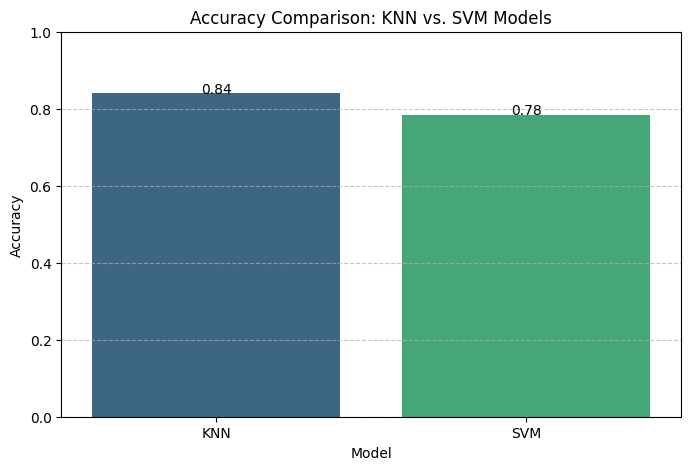

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

svm_accuracy = accuracy

knn_accuracy = 84.0 / 100

accuracy_data = {
    'Model': ['KNN', 'SVM'],
    'Accuracy': [knn_accuracy, svm_accuracy]
}
accuracy_df = pd.DataFrame(accuracy_data);

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=accuracy_df, palette='viridis', legend=False)
plt.title('Accuracy Comparison: KNN vs. SVM Models')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

for index, row in accuracy_df.iterrows():
    plt.text(index, row['Accuracy'], f'{row['Accuracy']:.2f}', color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()